# 🧭 Lesson 1: Data Cleaning & Interpretation
## 🎯 Goal
Learn how to prepare and understand real-world data, connect it to math/statistics, and extract initial insights.

### 1. Intuitive concept
Data cleaning = turning messy, incomplete, inconsistent data into reliable form so that you models can learn meaningful patterns.

Interpretation = understanding what your cleaned data is saying statistically.

Think of it like preparing before cooking.

| No matter how advanced you recipe (ML model), bad ingredients(data) will ruin the meal.

#### Why it Matters in Real AI / DataScience
Models like linear Regression, logistic regression, or neural networks all assume that your data:
- is numerical normalized,
- has no outliers dominating the loss function,
- reflects the true process, not random recording errors.

Bad data -> bad gradient direction -> poor optimization -> wrong prediction

### 2. Math connection

| Task     | Math/Stats Concept | Why It Matters |
|----------|--------------------|----------------|
|Handling Missing Values|Probability & Expectation|Mean/median imputation assumes data is missing at random (MAR).|
|Outlier Detection|IQR, z-score, standard deviation|Helps maintain representative data; prevents bias.|
|Feature Scaling|Normalization (Linear Algebra), Standardization, Variance (Statistics)|Keeps features on comparable scales; prevents domination by large values.|
|Correlation|Covariance Matrix (Linear Algebra)|Measures how variables move together; helps detect redundancy or relationships.|

### 3. Real-World Example

Let’s simulate a small dataset of students’ scores to show how cleaning + interpretation works.

In [1]:
# Example Data
import numpy as np
import pandas as pd

# create sample data
np.random.seed(42)
data = {
    "Student_ID": range(1,11),
    "Math_Score": [88, 92, np.nan, 70, 65, 90, 95, np.nan, 85, 60],
    "Science_Score": [78, 85, 80, 60, np.nan, 88, 90, 85, 82, 55],
    "Hours_Study": [np.nan, 10, 8, 4, 3, 9, 12, 8, np.nan, 2]
}

### 4. Cleaning Steps + Interpretation

#### Step 1: Check for Missing Data

In [11]:
df = pd.DataFrame(data)
print(df.isnull().sum())

Student_ID       0
Math_Score       2
Science_Score    1
Hours_Study      2
dtype: int64


We can see missing value in all three columns. Mathematically, we can think : missingness introduces uncertainity -> affects statistical expectation E[X]

#### Step 2: Handle Missing Data

Lets imputr using the column mean - assuming values are missing at random(a statistical assumption)

In [13]:
df_fitted = df.fillna(df.mean(numeric_only=True))
print(df_fitted.isnull().sum())

Student_ID       0
Math_Score       0
Science_Score    0
Hours_Study      0
dtype: int64


Now every columns has valid numerical values -> consider for analysis.

#### Step 3: Detect Outliers

Using z-score method = 𝑧 = (𝑥 − 𝜇) / 𝜎

In [21]:
z_score = np.abs((df_fitted - df_fitted.mean()) / df_fitted.std())
df_fitted[(z_score > 2).any(axis=1)]

,Student_ID,Math_Score,Science_Score,Hours_Study


Interpretation:

Rows with |z| > 2 are potential outliers.

Statistically, this means the value lies beyond 95% of the normal range.

#### Step 4: Basic Data Interpretation

Let’s look at correlations (a Linear Algebra concept via covariance matrix).

In [34]:
corr = df_fitted.corr(numeric_only=True)
corr

,Student_ID,Math_Score,Science_Score,Hours_Study
Student_ID,1.000000,-0.309282,-0.162847,-0.208893
Math_Score,-0.309282,1.000000,0.823816,0.949485
Science_Score,-0.162847,0.823816,1.000000,0.842408
Hours_Study,-0.208893,0.949485,0.842408,1.000000


<Axes: >

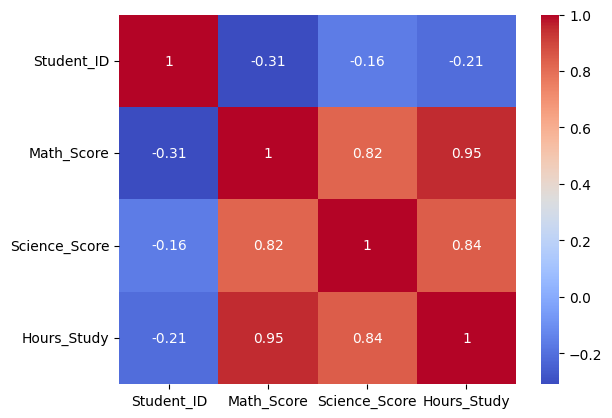

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(corr, annot=True, cmap="coolwarm")

Interpretation:

* If “Hours_Study” correlates strongly (r ≈ 0.7+) with “Math_Score” → studying more tends to improve scores (positive relationship).
* Correlation is not causation, but helps feature reasoning.

#### 5. Why It Matters in AI/ML

✅ Garbage in → Garbage out: Models can’t correct data quality issues.

✅ Missingness, outliers, or unscaled features distort learning.

✅ Every ML pipeline starts with clean, interpretable data.

## Exercise 1: Data Cleaning + Interpretation

Use the following steps on the dataset below:
```
data = {
    "Student_ID": range(1, 11),
    "Math_Score": [88, 92, np.nan, 70, 65, 90, 95, np.nan, 85, 60],
    "Science_Score": [78, 85, 80, 60, np.nan, 88, 90, 85, 82, 55],
    "Hours_Study": [np.nan, 10, 8, 4, 3, 9, 12, 8, np.nan, 2]
}
```

Check for Missing value
 Student_ID       0
Math_Score       2
Science_Score    1
Hours_Study      2
dtype: int64 
 ----------
Handel Missing value and replace by mean
 Student_ID       0
Math_Score       0
Science_Score    0
Hours_Study      0
dtype: int64 
 ----------
   Student_ID  Math_Score  Science_Score  Hours_Study
0    1.486301    0.618443       0.009563     0.000000
1    1.156012    0.953869       0.592928     0.948683
2    0.825723    0.000000       0.162577     0.316228
3    0.495434    0.890977       1.558828     0.948683
4    0.165145    1.310260       0.000000     1.264911
5    0.165145    0.786156       0.851139     0.632456
6    0.495434    1.205439       1.023279     1.581139
7    0.825723    0.000000       0.592928     0.316228
8    1.156012    0.366873       0.334718     0.000000
9    1.486301    1.729543       1.989179     1.581139
Check for the Outliers
 Empty DataFrame
Columns: [Student_ID, Math_Score, Science_Score, Hours_Study]
Index: [] 
 ----------
Correlatio

<Axes: >

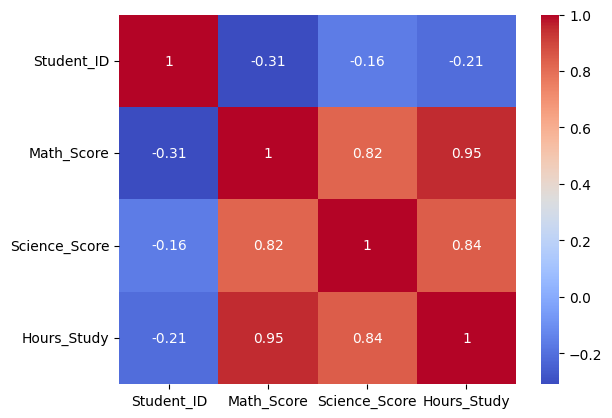

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data
data = {
    "Student_ID": range(1, 11),
    "Math_Score": [88, 92, np.nan, 70, 65, 90, 95, np.nan, 85, 60],
    "Science_Score": [78, 85, 80, 60, np.nan, 88, 90, 85, 82, 55],
    "Hours_Study": [np.nan, 10, 8, 4, 3, 9, 12, 8, np.nan, 2]
}

df = pd.DataFrame(data)

# 1. Check for Missing value
print("Check for Missing value\n",df.isnull().sum(),"\n", "-"*10)

# 2. Handel Missing value and replace by mean
df_fitted = df.fillna(df.mean(numeric_only=True))
print("Handel Missing value and replace by mean\n", df_fitted.isnull().sum(),"\n", "-"*10)

# 3. Detect the Outliers
z_score = np.abs((df_fitted - df_fitted.mean())/df_fitted.std())
print(z_score)
print("Check for the Outliers\n", df_fitted[(z_score > 2).any(axis=1)],"\n", "-"*10)

# 4. Correlation between all numeric columns.
corr = df_fitted.corr(numeric_only=True)
print("Correlation between all numeric columns\n", corr,"\n", "-"*10)

# 5. Visualization
sns.heatmap(corr, annot=True, cmap="coolwarm")

# 6. Interpretation
# Science_Score is strongly correlated with the Hours_Study. It means, students who spend their more hours studying scored highest in science.

## Exercise 2: Data Cleaning + Interpretation

Use the following steps on the dataset below:
```
data = {
    "Height": [165, 160, 172, 158, 400],
    "Weight": [70, np.nan, 78, 55, 80],
    "Gender": [M, F, M, F, M]
}
``

Raw data
    Height  Weight Gender
0     165    70.0      M
1     160     NaN      F
2     172    78.0      M
3     158    55.0      F
4     400    80.0      M
Missing values
 Height    0
Weight    1
Gender    0
dtype: int64
After Handeling missing values
    Height  Weight Gender
0     165    70.0      M
1     160    74.0      F
2     172    78.0      M
3     158    55.0      F
4     400    80.0      M
     Height    Weight Gender
0 -0.434814 -0.140848      M
1 -0.482077  0.261574      F
2 -0.368647  0.663996      M
3 -0.500982 -1.649929      F
4  1.786520  0.865207      M
Correlation
           Height    Weight
Height  1.000000  0.515665
Weight  0.515665  1.000000


<Axes: >

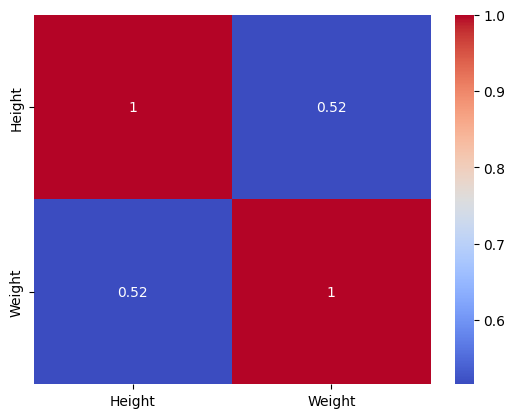

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

data = {
    "Height": [165, 160, 172, 158, 400],
    "Weight": [70, np.nan, 78, 55, 80],
    "Gender": ["M", "F", "M", "F", "M"]
}

df = pd.DataFrame(data)
print("Raw data\n",df)

# Check for the missing values
print("Missing values\n",df.isnull().sum())

# Handel missing values
df_fitted = df.fillna(df.median(numeric_only=True))
print("After Handeling missing values\n", df_fitted)

# Check for the outliers and cap outliers
z_score = np.abs((df_fitted["Height"] - df_fitted["Height"].mean())/df_fitted["Height"].std())
df_fitted.loc[z_score> 2.5, "Height"] = df_fitted["Height"].median()

z_score = np.abs((df_fitted["Weight"] - df_fitted["Weight"].mean())/df_fitted["Weight"].std())
df_fitted.loc[z_score > 2.5, "Weight"] = df_fitted["Weight"].median()

# Standardization
df_fitted["Height"] = (df_fitted["Height"] - df_fitted["Height"].mean())/df_fitted["Height"].std()
df_fitted["Weight"] = (df_fitted["Weight"] - df_fitted["Weight"].mean())/df_fitted["Weight"].std()
print(df_fitted)

# Correaltion
corr = df_fitted.corr(numeric_only=True)
print("Correlation\n", corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")

# Interpretation: Height and Weight are weakly correlated as thier correlation is 0.52